<a href="https://colab.research.google.com/github/azcsprof/ASU-CSE475-SS25/blob/Unit-3-ICE-3/Unit_3_ICE_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive CNN Exploration Lab

This lab walks you through building a Convolutional Neural Network (CNN) using PyTorch. It includes:
- Architecture design
- Interactive hyperparameter tuning (kernel size, filters, pooling)
- Shape visualization through each layer
- Optional: Running on MNIST test data with visual output

**Goal**: Understand CNN structure, how layers transform input, and how design choices impact output shape and performance.

In [1]:
!pip install -q torch torchvision torchinfo ipywidgets matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.7 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import ipywidgets as widgets
from torchinfo import summary
from IPython.display import display, clear_output
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## Define CNN Class with Dynamic Hyperparameters

This CNN includes a Conv2D layer, ReLU, AvgPool2D, and a final Linear layer. Output shape is computed dynamically.

In [7]:
class CNN(nn.Module):
    def __init__(self, in_channels=1, out_channels=8, kernel_size=3, pool_size=2):
        super(CNN, self).__init__()
        self.kernel_size = kernel_size
        self.pool_size = pool_size
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size)
        self.pool = nn.AvgPool2d(pool_size)

        conv_output_size = 100 - kernel_size + 1
        if conv_output_size % pool_size != 0:
            raise ValueError(f"Conv output size {conv_output_size} not divisible by pool size {pool_size}")
        pooled_size = conv_output_size // pool_size

        self.flattened = out_channels * pooled_size * pooled_size
        self.fc = nn.Linear(self.flattened, 10)

    def forward(self, x, verbose=False):
        shapes = {'Input': x.shape}
        x = F.relu(self.conv(x))
        shapes['Conv+ReLU'] = x.shape
        x = self.pool(x)
        shapes['Pooled'] = x.shape
        x = x.view(x.size(0), -1)
        shapes['Flattened'] = x.shape
        x = self.fc(x)
        shapes['Output'] = x.shape
        if verbose:
            for k, v in shapes.items():
                print(f"{k}: {v}")
        return x, shapes

## Interactive Model Designer + Shape Plot
Use the sliders to explore how filter count, kernel size, and pooling affect the shape of each layer in the CNN.

In [14]:
def draw_shape_diagram(shapes):
    stages = list(shapes.keys())
    dims = [list(shapes[k])[1:] for k in stages]  # skip batch

    fig, ax = plt.subplots(figsize=(12, 2))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # layer colors

    # Plot each layer's feature volume as independent bars
    for i, (stage, dim) in enumerate(zip(stages, dims)):
        total_size = torch.tensor(dim).prod().item()
        ax.barh(i, total_size, height=0.6, color=colors[i % len(colors)],
                label=f"{stage} {dim}")

    ax.set_yticks(range(len(stages)))
    ax.set_yticklabels(stages)
    ax.set_xlabel("Total Number of Features")
    ax.set_title("CNN Layer Output Sizes (Feature Volume)")
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    plt.show()

In [15]:
out_channels_slider = widgets.IntSlider(value=8, min=2, max=32, step=2, description='Filters')
kernel_slider = widgets.IntSlider(value=3, min=1, max=7, step=2, description='Kernel Size')
pool_slider = widgets.IntSlider(value=2, min=1, max=5, step=1, description='Pool Size')
run_button = widgets.Button(description="Run CNN")
output = widgets.Output()

def on_run_button_clicked(b):
    with output:
        clear_output()
        x = torch.randn(1, 1, 100, 100)
        try:
            model = CNN(
                in_channels=1,
                out_channels=out_channels_slider.value,
                kernel_size=kernel_slider.value,
                pool_size=pool_slider.value
            )
            _, shapes = model(x, verbose=True)
            draw_shape_diagram(shapes)
            print("\nModel Summary:")
            summary(model, input_size=(1, 1, 100, 100), verbose=0)
        except Exception as e:
            print("❌ Error:", e)

run_button.on_click(on_run_button_clicked)
display(widgets.VBox([out_channels_slider, kernel_slider, pool_slider, run_button, output]))

## Bonus: Run on Real MNIST Data and See Predictions

🧪 Initial accuracy on 100 test samples: 11.00%



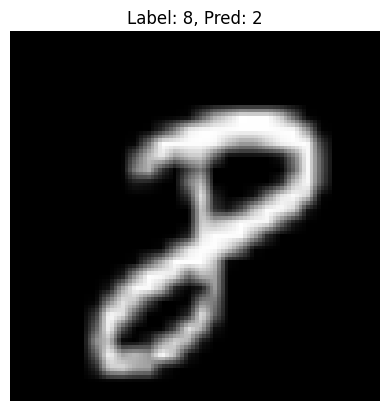

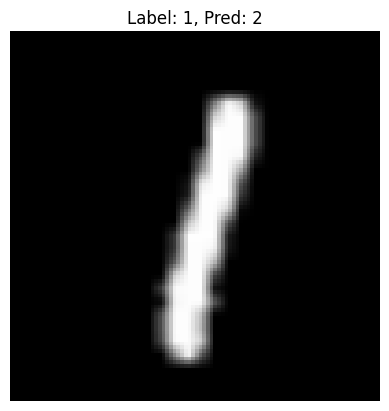

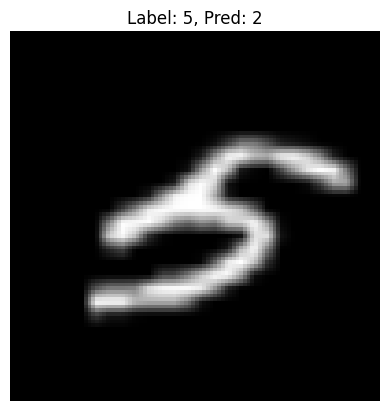

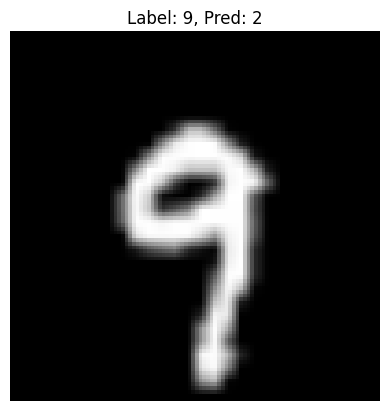

In [19]:
# 🔍 Pre-training evaluation on 100 MNIST test samples
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])
mnist_test = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(mnist_test, batch_size=4, shuffle=True)

# Initialize CNN with widget parameters
model = CNN(1, out_channels_slider.value, kernel_slider.value, pool_slider.value)
model.eval()

# Check accuracy on first 100 samples
correct, total = 0, 0
with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        outputs, _ = model(images)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        if total >= 100:  # Only check first 100 samples
            break
initial_acc = 100 * correct / total
print(f"🧪 Initial accuracy on 100 test samples: {initial_acc:.2f}%\n")

# Display 4 predictions from next test batch
images, labels = next(iter(test_loader))
with torch.no_grad():
    outputs, _ = model(images)
    preds = torch.argmax(outputs, dim=1)

for i in range(4):
    plt.imshow(images[i][0], cmap="gray")
    plt.title(f"Label: {labels[i].item()}, Pred: {preds[i].item()}")
    plt.axis("off")
    plt.show()

In [17]:
# Load training data with transform
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(mnist_train, batch_size=32, shuffle=True)

Training on 1,000 samples...

Epoch 1: Loss = 40.70, Accuracy = 56.84%
Epoch 2: Loss = 15.40, Accuracy = 85.25%
Epoch 3: Loss = 14.10, Accuracy = 85.84%

Testing on 5 unseen MNIST digits:


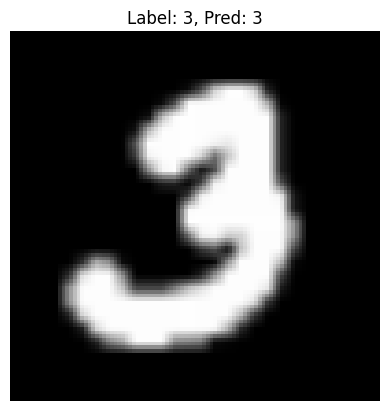

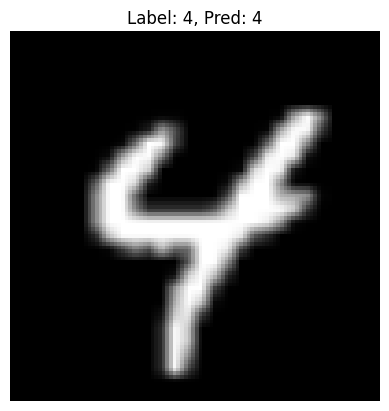

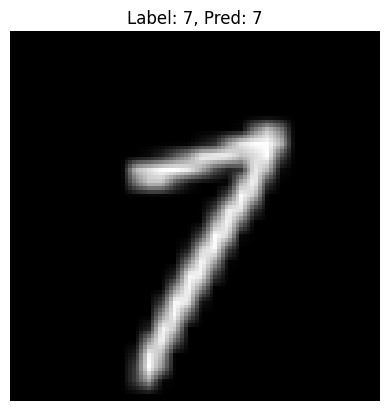

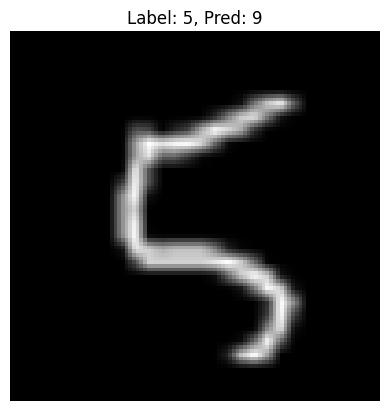

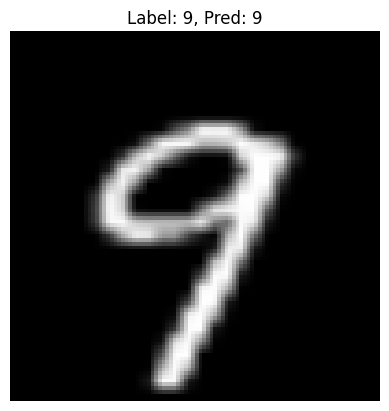

In [18]:
# 🔁 Train the model on 1,000 training samples for 3 epochs
model = CNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("Training on 1,000 samples...\n")
for epoch in range(3):
    model.train()
    correct, total, loss_sum = 0, 0, 0.0

    for i, (x_batch, y_batch) in enumerate(train_loader):
        if i * 32 > 1000: break  # Only use ~1,000 samples
        optimizer.zero_grad()
        output, _ = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        preds = torch.argmax(output, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}: Loss = {loss_sum:.2f}, Accuracy = {accuracy:.2f}%")

# 🧪 Evaluate on 5 test samples
print("\nTesting on 5 unseen MNIST digits:")
model.eval()
count = 0
for x_test, y_test in test_loader:
    with torch.no_grad():
        out, _ = model(x_test)
        pred = torch.argmax(out, dim=1)

    plt.imshow(x_test[0][0], cmap="gray")
    plt.title(f"Label: {y_test[0].item()}, Pred: {pred[0].item()}")
    plt.axis("off")
    plt.show()

    count += 1
    if count >= 5:
        break